In [1]:
import os
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt

# Path of downloaded and extracted Kaggle dataset
data_path = r"E:\lebika_training\dataset"

# Find the 4 category folders
classes = []

for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)
    
    if os.path.isdir(folder_path):
        classes.append(folder)

print("Classes:")
print(classes)

print("\nNumber of classes:", len(classes))

Classes:
['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']

Number of classes: 4



--- Class Distribution ---
category
comp.graphics         100
rec.sport.baseball    100
sci.space             100
talk.politics.misc    100
Name: count, dtype: int64

--- Summary Statistics (Word Counts) ---
                    count    mean          std    min     25%    50%    75%  \
category                                                                      
comp.graphics       100.0  538.50  1493.784560   88.0  164.75  210.0  304.5   
rec.sport.baseball  100.0  309.88   212.465435   94.0  166.50  239.5  363.5   
sci.space           100.0  427.32   593.681969   75.0  205.50  277.5  450.0   
talk.politics.misc  100.0  511.47   786.409710  118.0  261.75  321.5  441.0   

                        max  
category                     
comp.graphics       10128.0  
rec.sport.baseball   1245.0  
sci.space            5498.0  
talk.politics.misc   7122.0  


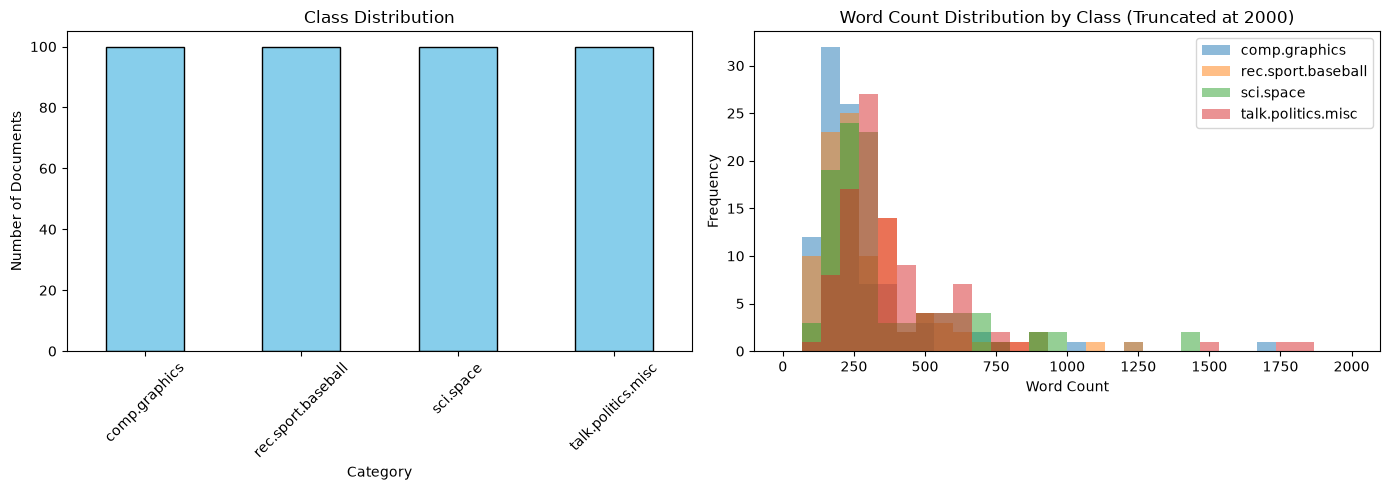

In [8]:
# 1. Load documents and calculate properties into a Pandas DataFrame
data = []

for category in classes:
    category_path = os.path.join(data_path, category)
    for filename in os.listdir(category_path):
        file_path = os.path.join(category_path, filename)
        
        # Ensure we are reading files only
        if os.path.isfile(file_path):
            try:
                with open(file_path, 'r', encoding='latin-1') as file:
                    content = file.read()
                    
                    # Calculate character length and word count
                    char_length = len(content)
                    word_count = len(re.findall(r'\w+', content))
                    
                    data.append({
                        'category': category,
                        'filename': filename,
                        'char_length': char_length,
                        'word_count': word_count
                    })
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

# Convert list to DataFrame
df = pd.DataFrame(data)

# 2. Analyze Class Distribution
print("\n--- Class Distribution ---")
class_counts = df['category'].value_counts()
print(class_counts)

# 3. Analyze Document Length Statistics
print("\n--- Summary Statistics (Word Counts) ---")
print(df.groupby('category')['word_count'].describe())

# 4. Plot Class Distribution & Document Length Distributions
plt.figure(figsize=(14, 5))

# Plot 1: Class Distribution
plt.subplot(1, 2, 1)
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Documents')
plt.xticks(rotation=45)

# Plot 2: Document Word Count Distribution
plt.subplot(1, 2, 2)
for category in classes:
    subset = df[df['category'] == category]
    plt.hist(subset['word_count'], bins=30, alpha=0.5, label=category, range=(0, 2000))

plt.title('Word Count Distribution by Class (Truncated at 2000)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# Display 1 sample document snippet from each of the 4 categories
for category in classes:
    category_path = os.path.join(data_path, category)
    
    # Grab the first file in the directory
    filename = os.listdir(category_path)[0]
    file_path = os.path.join(category_path, filename)
    
    try:
        with open(file_path, 'r', encoding='latin-1') as f:
            content = f.read()
            
            print("=" * 60)
            print(f"CATEGORY: {category} | FILE: {filename}")
            print("=" * 60)
            # Print the first 300 characters as a preview
            print(content[:300].strip())
            print("\n")
            
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")

CATEGORY: comp.graphics | FILE: 37916
Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!fs7.ece.cmu.edu!europa.eng.gtefsd.com!gatech!asuvax!cs.utexas.edu!zaphod.mps.ohio-state.edu!saimiri.primate.wisc.edu!usenet.coe.montana.edu!news.u.washington.edu!uw-beaver!cs.ubc.ca!unixg.ubc.ca!kakwa.ucs.ualberta.ca!ersys!joth
From: joth@ersy


CATEGORY: rec.sport.baseball | FILE: 102590
Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!fs7.ece.cmu.edu!europa.eng.gtefsd.com!gatech!news-feed-1.peachnet.edu!umn.edu!msus1.msus.edu!mhd.moorhead.msus.edu!HOLSEND
Newsgroups: rec.sport.baseball
Subject: Re: DESIGNATED HITTER RULE
Message-ID: <1993Apr5.135452.2952@msus1.msus.edu>
Fro


CATEGORY: sci.space | FILE: 59848
Xref: cantaloupe.srv.cs.cmu.edu sci.space:59848 sci.answers:100 news.answers:7198
Path: cantaloupe.srv.cs.cmu.edu!das-news.harvard.edu!ogicse!decwrl!concert!borg.cs.unc.edu!not-for-mail
From: leech@cs.unc.edu (Jon Leech)
Newsgroups: sci.space,sci.answers,news.answers
Subject: S

Total Words (Tokens): 166,370
Vocabulary Size (Unique Words): 14,703

--- Top 20 Most Frequent Words ---
    Word  Frequency
0    the       6560
1    edu       3475
2     to       3411
3     of       2938
4      a       2720
5    and       2641
6     in       2041
7     is       1794
8   that       1687
9      i       1685
10   for       1464
11    it       1427
12   you       1204
13   cmu       1067
14     s       1037
15    on       1022
16  from       1004
17   com        984
18    cs        980
19  this        842


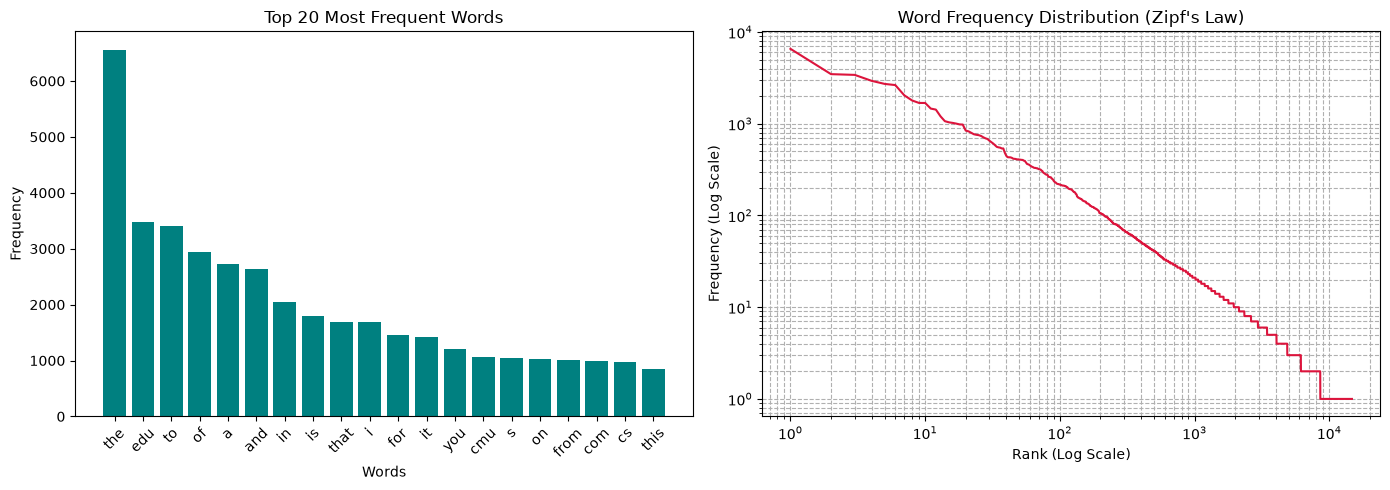

In [10]:
# 1. Collect all words from the dataset across all categories
all_words = []

for category in classes:
    category_path = os.path.join(data_path, category)
    for filename in os.listdir(category_path):
        file_path = os.path.join(category_path, filename)

        if os.path.isfile(file_path):
            try:
                with open(file_path, "r", encoding="latin-1") as file:
                    content = file.read().lower()  # Lowercase for uniform counting
                    words = re.findall(r"\b[a-z]+\b", content)  # Extract alphabetic words
                    all_words.extend(words)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

# 2. Vocabulary Statistics
word_counts = Counter(all_words)
total_words = len(all_words)
vocab_size = len(word_counts)

print(f"Total Words (Tokens): {total_words:,}")
print(f"Vocabulary Size (Unique Words): {vocab_size:,}")

# 3. Word Frequency Summary
freq_df = pd.DataFrame(
    word_counts.most_common(20), columns=["Word", "Frequency"]
)
print("\n--- Top 20 Most Frequent Words ---")
print(freq_df)

# 4. Plot Word Frequency Distribution (Zipf's Law)
plt.figure(figsize=(14, 5))

# Plot 1: Top 20 Most Frequent Words
plt.subplot(1, 2, 1)
plt.bar(freq_df["Word"], freq_df["Frequency"], color="teal")
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

# Plot 2: Log-Log Plot of Word Frequencies (Zipf's Law)
frequencies = list(word_counts.values())
frequencies.sort(reverse=True)

plt.subplot(1, 2, 2)
plt.loglog(range(1, len(frequencies) + 1), frequencies, color="crimson")
plt.title("Word Frequency Distribution (Zipf's Law)")
plt.xlabel("Rank (Log Scale)")
plt.ylabel("Frequency (Log Scale)")
plt.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()